# NO₂ Model Diagnostics

Three deep-dive diagnostics using the **fully-trained** Transformer and Mamba checkpoints:

| # | Analysis | What it shows |
|---|---|---|
| 3 | **Forecast error time decomposition** | MAE grouped by hour-of-day and month — *when* do models fail most? |
| 4 | **Attention weight visualisation** | Which past hours the Transformer attends to most |
| 5 | **Residual autocorrelation (ACF/PACF)** | Serial structure in prediction errors the model has not captured |

All figures are saved to `../plots/`.

In [1]:
import sys, os
from pathlib import Path

_here = Path(os.getcwd()).resolve()
ROOT  = _here.parent if _here.name == 'notebooks' else _here
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from data.load_airnow import load_sequences
from models.transformer_no2 import NO2Transformer
from models.mamba_no2 import NO2Mamba

OUTPUTS_DIR = ROOT / 'outputs'
PLOTS_DIR   = ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
SEQ_LEN  = 24
PRED_LEN = 6

# ── ACF / PACF helpers (pure numpy — no statsmodels needed) ──────────────────
def _acf_vals(x, nlags=48):
    """Normalized autocorrelation via FFT + 95 % confidence band."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x);  x = x - x.mean()
    f   = np.fft.fft(x, n=2 * n)
    acov = np.fft.ifft(f * np.conj(f)).real[:n] / n
    r   = acov / acov[0]
    ci  = 1.96 / np.sqrt(n)
    return r[:nlags + 1], ci

def _pacf_vals(x, nlags=48):
    """PACF via Levinson-Durbin recursion + 95 % confidence band."""
    r, ci = _acf_vals(x, nlags=nlags)
    pacf = [1.0]
    phi  = np.array([r[1]])
    pacf.append(phi[0])
    for k in range(2, nlags + 1):
        num   = r[k] - np.dot(phi, r[1:k][::-1])
        den   = 1.0  - np.dot(phi, r[1:k])
        phi_k = num / den if abs(den) > 1e-12 else 0.0
        phi   = np.append(phi - phi_k * phi[::-1], phi_k)
        pacf.append(phi_k)
    return np.array(pacf), ci

def _plot_corr(ax, vals, ci, lag24_color='crimson', lag48_color='darkorange', title=''):
    lags = np.arange(len(vals))
    ax.bar(lags, vals, color='steelblue', alpha=0.7, width=0.6)
    ax.fill_between([-1, len(vals)], -ci, ci,
                    color='royalblue', alpha=0.08)
    ax.axhline( ci, color='royalblue', lw=0.9, ls='--')
    ax.axhline(-ci, color='royalblue', lw=0.9, ls='--')
    ax.axhline(0,   color='black',     lw=0.6)
    ax.axvline(24,  color=lag24_color,  lw=0.9, ls='--', alpha=0.7, label='24 h (daily)')
    ax.axvline(48,  color=lag48_color,  lw=0.9, ls='--', alpha=0.7, label='48 h')
    ax.set_xlim(-1, len(vals))
    ax.set_ylim(-0.5, 1.05)
    ax.set_title(title)
    ax.set_xlabel('Lag (hours)')
# ─────────────────────────────────────────────────────────────────────────────

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print(f'ROOT    : {ROOT}')
print(f'Device  : {DEVICE}')


ROOT    : /mnt/data3/isybelle1118/NO2 Forecasting
Device  : cuda


In [2]:
print('Loading sequences …')
X, y, timestamps, sites = load_sequences(seq_len=SEQ_LEN, pred_len=PRED_LEN)
N_SITES = len(sites)

n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_test  = X[n_train + n_val:]
y_test  = y[n_train + n_val:]
ts_test = timestamps[n_train + n_val:]   # list of pd.Timestamp (start of each X window)

print(f'Test windows : {len(X_test):,}  ({ts_test[0]} → {ts_test[-1]})')
print(f'Sites        : {N_SITES}')

Loading sequences …


Test windows : 1,645  (2024-07-23 06:00:00 → 2024-09-29 18:00:00)
Sites        : 197


In [3]:
def _load_model(ModelClass, ckpt_path, **kwargs):
    m = ModelClass(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN, **kwargs)
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    m.load_state_dict(state)
    return m.to(DEVICE).eval()

tf_model = _load_model(NO2Transformer, OUTPUTS_DIR / 'transformer_s24_p6_d128.pt')
mb_model = _load_model(NO2Mamba,       OUTPUTS_DIR / 'mamba_s24_p6_d128.pt')

print(f'Transformer params : {sum(p.numel() for p in tf_model.parameters()):,}')
print(f'Mamba params       : {sum(p.numel() for p in mb_model.parameters()):,}')

Transformer params : 3,922,590
Mamba params       : 4,020,126


In [4]:
@torch.no_grad()
def predict_all(model, X, batch_size=256):
    """Batch inference → numpy array (n, pred_len, n_sites)."""
    preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.tensor(X[i : i + batch_size]).to(DEVICE)
        preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)

print('Running inference on test set …')
tf_pred = predict_all(tf_model, X_test)   # (n_test, 6, 197)
mb_pred = predict_all(mb_model, X_test)

tf_mae_raw = np.abs(tf_pred - y_test)     # element-wise MAE (n_test, 6, 197)
mb_mae_raw = np.abs(mb_pred - y_test)

# Signed residuals averaged over sites and pred steps
tf_resid = (tf_pred - y_test).mean(axis=(1, 2))   # (n_test,)
mb_resid = (mb_pred - y_test).mean(axis=(1, 2))

print(f'Transformer test MAE : {tf_mae_raw.mean():.4f}')
print(f'Mamba       test MAE : {mb_mae_raw.mean():.4f}')

Running inference on test set …


Transformer test MAE : 0.6991
Mamba       test MAE : 0.7467


## 3. Forecast Error Time Decomposition

Average MAE grouped by **hour of day** (UTC) and **month of year** for the test-set predictions.
The grouping key is the hour/month of the *first predicted timestep* (= window start + `SEQ_LEN` hours).

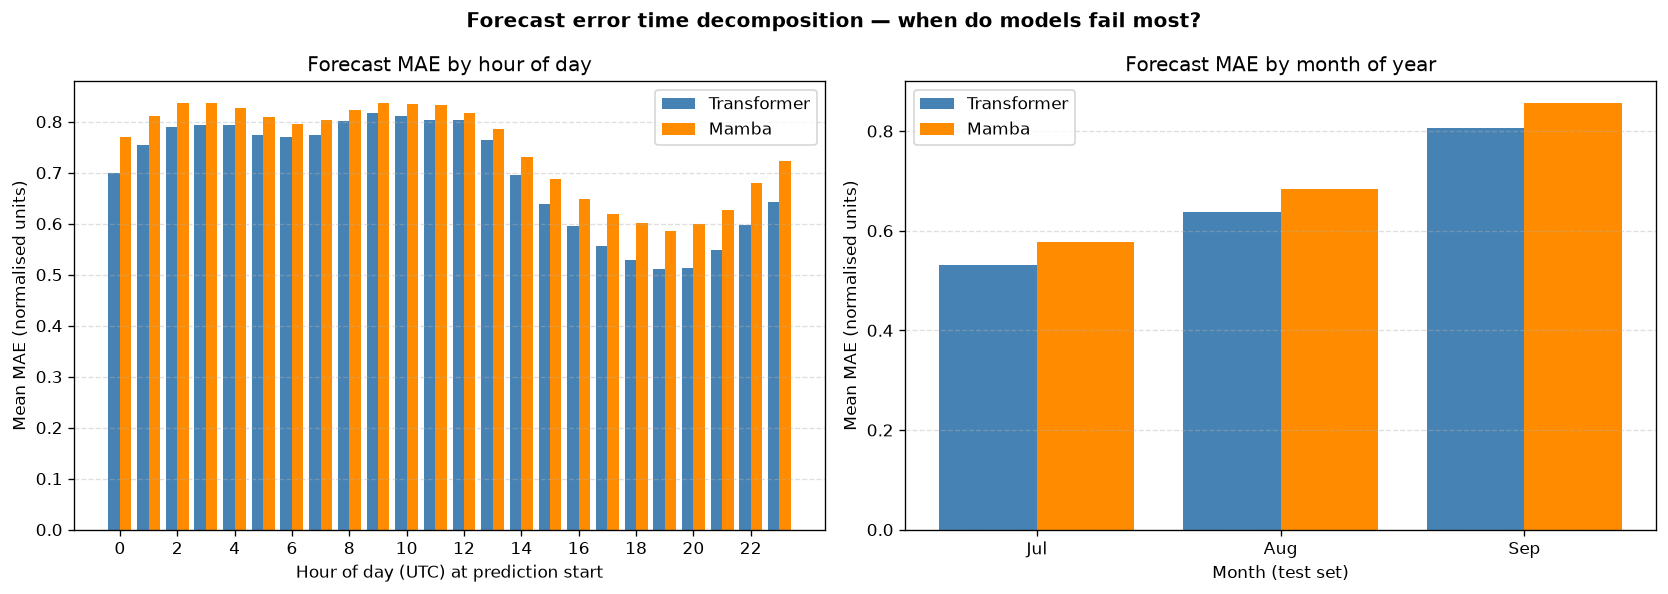

Saved diag_error_decomp.png


In [5]:
# Timestamps of the first predicted hour for each test window
pred_hour  = np.array([(ts + pd.Timedelta(hours=SEQ_LEN)).hour  for ts in ts_test])
pred_month = np.array([(ts + pd.Timedelta(hours=SEQ_LEN)).month for ts in ts_test])

# Collapse pred_len and n_sites → one MAE scalar per test window
mae_tf = tf_mae_raw.mean(axis=(1, 2))   # (n_test,)
mae_mb = mb_mae_raw.mean(axis=(1, 2))

# --- By hour of day ---
tf_by_hour = [mae_tf[pred_hour == h].mean() for h in range(24)]
mb_by_hour = [mae_mb[pred_hour == h].mean() for h in range(24)]

# --- By month ---
months_present = sorted(set(pred_month))
month_labels   = [pd.Timestamp(2024, m, 1).strftime('%b') for m in months_present]
tf_by_month    = [mae_tf[pred_month == m].mean() for m in months_present]
mb_by_month    = [mae_mb[pred_month == m].mean() for m in months_present]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x24 = np.arange(24)
ax1.bar(x24 - 0.2, tf_by_hour, width=0.4, color='steelblue',  label='Transformer')
ax1.bar(x24 + 0.2, mb_by_hour, width=0.4, color='darkorange', label='Mamba')
ax1.set_xlabel('Hour of day (UTC) at prediction start')
ax1.set_ylabel('Mean MAE (normalised units)')
ax1.set_title('Forecast MAE by hour of day')
ax1.set_xticks(range(0, 24, 2))
ax1.legend()
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)

xm = np.arange(len(months_present))
ax2.bar(xm - 0.2, tf_by_month, width=0.4, color='steelblue',  label='Transformer')
ax2.bar(xm + 0.2, mb_by_month, width=0.4, color='darkorange', label='Mamba')
ax2.set_xticks(xm)
ax2.set_xticklabels(month_labels)
ax2.set_xlabel('Month (test set)')
ax2.set_ylabel('Mean MAE (normalised units)')
ax2.set_title('Forecast MAE by month of year')
ax2.legend()
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Forecast error time decomposition — when do models fail most?',
             fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'diag_error_decomp.png', dpi=150)
plt.show()
print('Saved diag_error_decomp.png')

## 4. Attention Weight Visualisation

For each Transformer encoder layer, extract the self-attention weight matrix
averaged over heads and over 200 test-set samples.

**How to read the heatmap:** Row = query position (which output hour is attending),
Column = key position (which past hour is being attended to).
Bright cells = the model assigns high importance to that key when computing that query.
A bright diagonal means the model mostly attends to the same time step (local context);
bright columns on the right mean the most recent hours dominate.

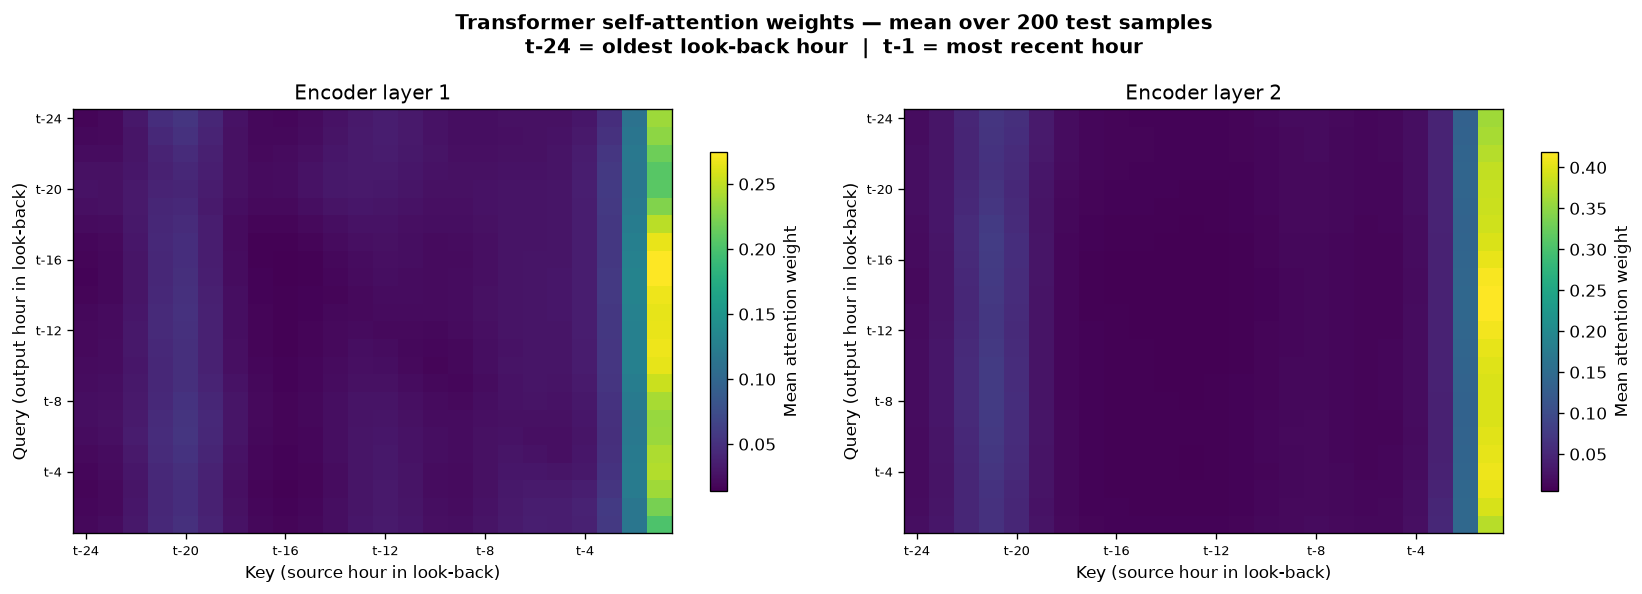

Saved diag_attention_weights.png


In [6]:
@torch.no_grad()
def extract_attention(model, x_np, n_samples=200):
    """Return mean self-attention weights (n_layers, seq_len, seq_len) averaged over n_samples."""
    x = torch.tensor(x_np[:n_samples]).to(DEVICE)
    h = model.pos_enc(model.input_proj(x))
    all_weights = []
    for layer in model.encoder.layers:
        # Extract weights before this layer processes h (pre-layer attention)
        _, w = layer.self_attn(h, h, h,
                               need_weights=True, average_attn_weights=True)
        all_weights.append(w.cpu().numpy())   # (n_samples, seq_len, seq_len)
        h = layer(h)   # continue normal forward to get correct h for next layer
    return np.stack(all_weights, axis=1).mean(axis=0)  # (n_layers, seq_len, seq_len)

mean_attn = extract_attention(tf_model, X_test)   # (n_layers, 24, 24)
n_layers  = mean_attn.shape[0]

tick_pos    = list(range(0, SEQ_LEN, 4))
tick_labels = [f't-{SEQ_LEN - i}' for i in tick_pos]

fig, axes = plt.subplots(1, n_layers, figsize=(7 * n_layers, 5))
if n_layers == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    im = ax.imshow(mean_attn[i], cmap='viridis', aspect='auto', origin='upper')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Mean attention weight')
    ax.set_xlabel('Key (source hour in look-back)')
    ax.set_ylabel('Query (output hour in look-back)')
    ax.set_title(f'Encoder layer {i + 1}')
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels, fontsize=8)

plt.suptitle(
    f'Transformer self-attention weights — mean over {min(200, len(X_test))} test samples\n'
    f't-{SEQ_LEN} = oldest look-back hour  |  t-1 = most recent hour',
    fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'diag_attention_weights.png', dpi=150)
plt.show()
print('Saved diag_attention_weights.png')

## 5. Residual Autocorrelation (ACF / PACF)

Residuals = mean(predicted − actual) across all sites and prediction steps, per test window.

- **ACF**: If significant spikes exist at lag *k*, the model's errors are correlated *k* hours apart — structure it is missing.
- **PACF**: Shows the direct (non-mediated) correlation at each lag after removing shorter-lag effects.
- Lags 24 and 48 correspond to a daily cycle — spikes there mean the model has not fully captured the diurnal rhythm.

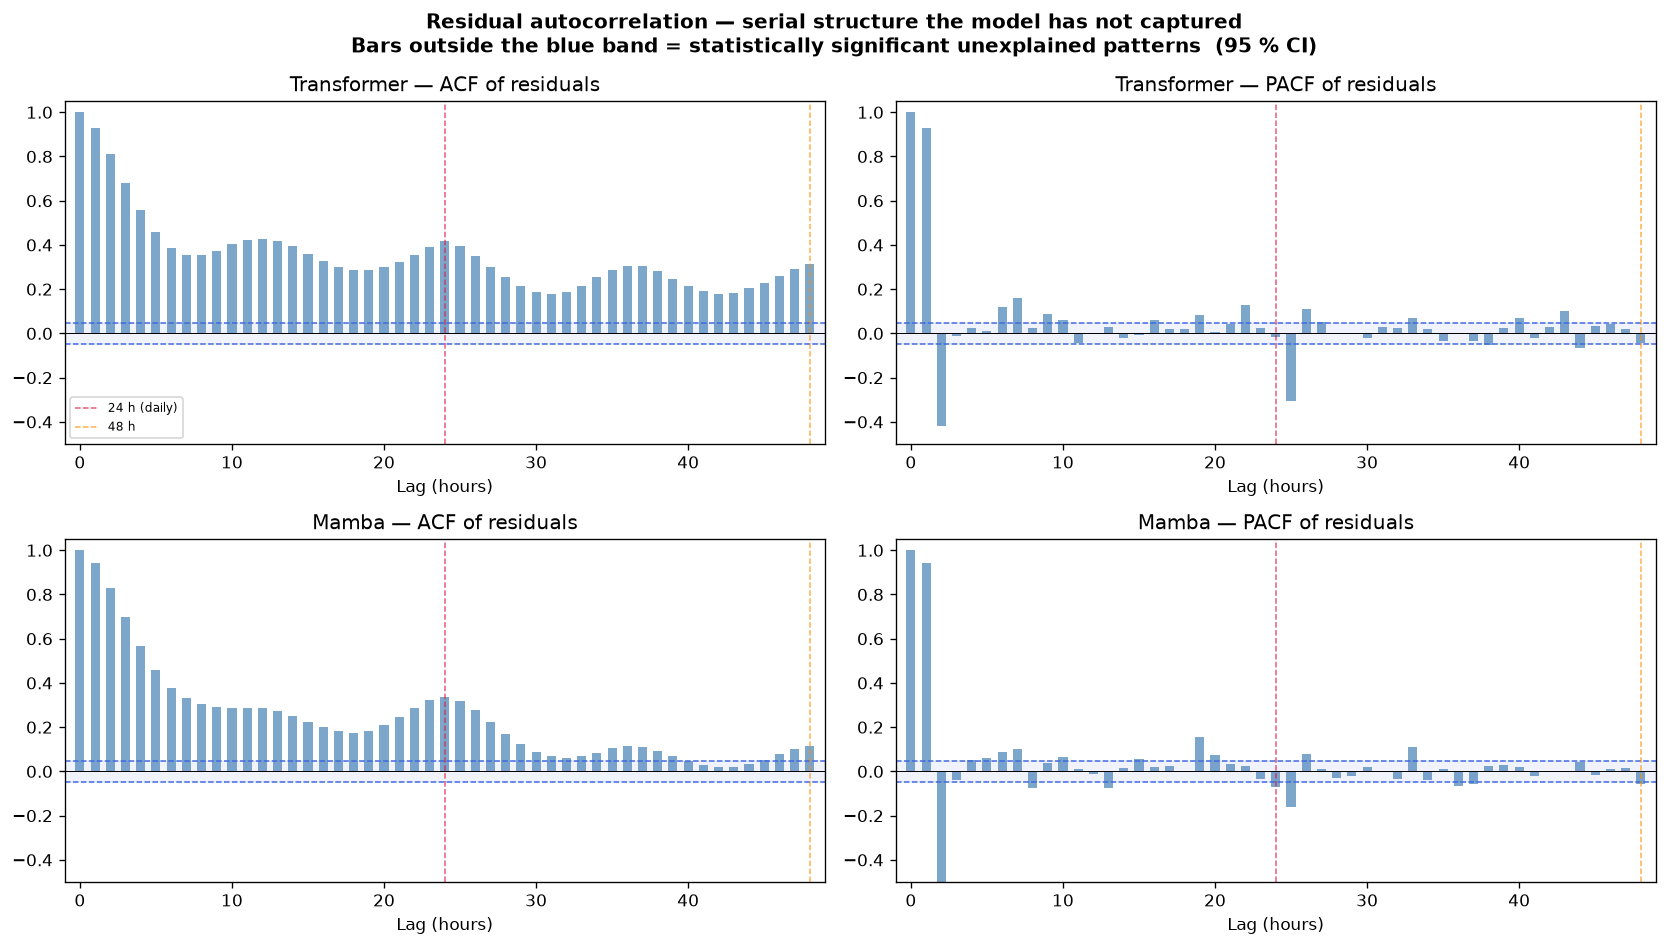

Saved diag_residual_acf.png


In [7]:
pred_times = [ts + pd.Timedelta(hours=SEQ_LEN) for ts in ts_test]
tf_resid_s = pd.Series(tf_resid, index=pred_times)
mb_resid_s = pd.Series(mb_resid, index=pred_times)

NLAGS = 48
tf_acf,  tf_acf_ci  = _acf_vals( tf_resid_s.values, nlags=NLAGS)
tf_pacf, tf_pacf_ci = _pacf_vals(tf_resid_s.values, nlags=NLAGS)
mb_acf,  mb_acf_ci  = _acf_vals( mb_resid_s.values, nlags=NLAGS)
mb_pacf, mb_pacf_ci = _pacf_vals(mb_resid_s.values, nlags=NLAGS)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

_plot_corr(axes[0, 0], tf_acf,  tf_acf_ci,  title='Transformer — ACF of residuals')
_plot_corr(axes[0, 1], tf_pacf, tf_pacf_ci, title='Transformer — PACF of residuals')
_plot_corr(axes[1, 0], mb_acf,  mb_acf_ci,  title='Mamba — ACF of residuals')
_plot_corr(axes[1, 1], mb_pacf, mb_pacf_ci, title='Mamba — PACF of residuals')

axes[0, 0].legend(fontsize=7)

plt.suptitle(
    'Residual autocorrelation — serial structure the model has not captured\n'
    'Bars outside the blue band = statistically significant unexplained patterns  '
    '(95 % CI)',
    fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'diag_residual_acf.png', dpi=150)
plt.show()
print('Saved diag_residual_acf.png')
